# World Population Analysis 

## Objective

Data analysis focused on analyzing world population data using Python and SQL 


In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("../data/world_population.csv")
df.head()


,country,continent,year,population
0,China,Asia,2000,1262645000
1,China,Asia,2020,1402112000
2,India,Asia,2000,1056575549
3,India,Asia,2020,1380004385
4,United States,North America,2000,282162411


## Data Overview

I am starting by exploring the structure of the dataset and understanding its main columns: country, continent, year, and population.


In [3]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   country     16 non-null     object
 1   continent   16 non-null     object
 2   year        16 non-null     int64 
 3   population  16 non-null     int64 
dtypes: int64(2), object(2)
memory usage: 640.0+ bytes


,year,population
count,16.000000,1.600000e+01
mean,2010.000000,4.308558e+08
std,10.327956,5.151090e+08
min,2000.000000,1.915300e+07
25%,2000.000000,1.125230e+08
50%,2010.000000,1.904650e+08
75%,2020.000000,5.127308e+08
max,2020.000000,1.402112e+09


## Population Growth

I will calculate population growth for each country between 2000 and 2020 and sort countries by growth rate.


In [4]:
growth = df.pivot(index="country", columns="year", values="population")
growth["growth_rate"] = ((growth[2020] - growth[2000]) / growth[2000]) * 100
growth = growth.sort_values("growth_rate", ascending=False)
growth


year,2000,2020,growth_rate
country,,,
Nigeria,122283853,206139587,68.574658
Australia,19153000,25687041,34.114974
India,1056575549,1380004385,30.611047
Brazil,174790340,212559409,21.608213
United States,282162411,331449281,17.467553
China,1262645000,1402112000,11.045622
Germany,82211508,83240525,1.251670
Japan,126843000,125836021,-0.793878


In [5]:
continent_map = df[["country", "continent"]].drop_duplicates()
growth = growth.merge(continent_map, on="country")
growth


,country,2000,2020,growth_rate,continent
0,Nigeria,122283853,206139587,68.574658,Africa
1,Australia,19153000,25687041,34.114974,Oceania
2,India,1056575549,1380004385,30.611047,Asia
3,Brazil,174790340,212559409,21.608213,South America
4,United States,282162411,331449281,17.467553,North America
5,China,1262645000,1402112000,11.045622,Asia
6,Germany,82211508,83240525,1.251670,Europe
7,Japan,126843000,125836021,-0.793878,Asia


## Visualization 1 – Population by Continent (2020)

Bar chart showing the total population per continent in 2020.


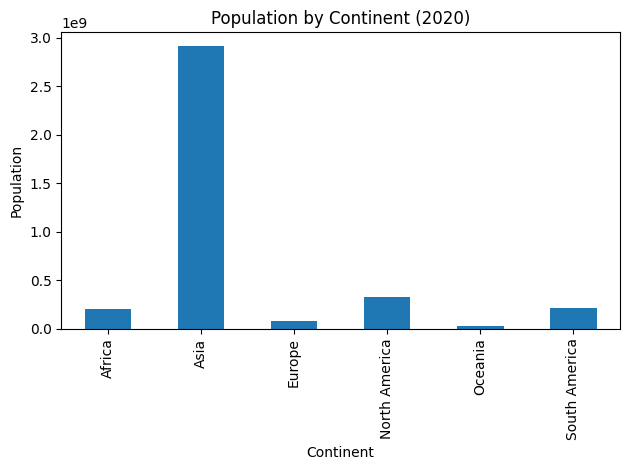

In [6]:
pop_2020 = df[df["year"] == 2020]
continent_pop = pop_2020.groupby("continent")["population"].sum()

plt.figure()
continent_pop.plot(kind="bar")
plt.title("Population by Continent (2020)")
plt.xlabel("Continent")
plt.ylabel("Population")
plt.tight_layout()
plt.savefig("../visuals/population_by_continent.png")
plt.show()


## Visualization 2 – Top 5 Countries by Population Growth (2000–2020)

Bar chart showing the top 5 countries with the highest population growth.


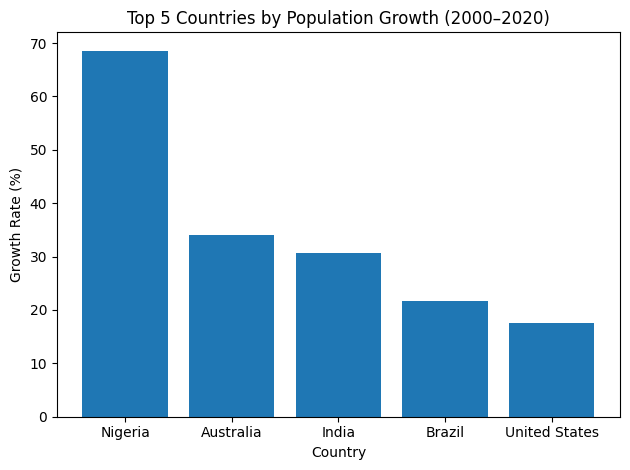

In [7]:
top_growth = growth.sort_values("growth_rate", ascending=False).head(5)

plt.figure()
plt.bar(top_growth["country"], top_growth["growth_rate"])
plt.title("Top 5 Countries by Population Growth (2000–2020)")
plt.xlabel("Country")
plt.ylabel("Growth Rate (%)")
plt.tight_layout()
plt.savefig("../visuals/top_growth_countries.png")
plt.show()


## Key Insights

- Asia has the largest population in 2020, led by China and India.
- Nigeria shows one of the highest population growth rates over the last 20 years.
- Developed countries like Germany and Japan have low or negative growth rates.
- Oceania has the smallest population but has seen steady growth.
- Top population growth countries are mostly in Africa and Asia, reflecting emerging economies.
